# HDB Resale Portal — Did It Work?

4 questions:
1. Portal helpful? (self-serve up? market faster?)
2. Hurt agents' business?
3. Market overall — what changed?
4. Adoption differ by town?

Data: CEA agent records (1 row = 1 agent, 1 side, 1 deal) + HDB ResaleFlatPrices
(1 row = 1 sale, whole market). No shared ID — compare trends, not rows.

CEA filtered to HDB + RESALE only. Same segment the portal targets. Also dodges
a 2020 rental-reporting jump, unrelated to the portal.

Years: 2017-2025 for yearly charts. 2026 = partial year, monthly only.

Outputs: `output/data/*.csv` + `summary.json`, `output/charts/*.png`.

In [1]:
import json
import re
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

%matplotlib inline

def find_data_dir(start: Path) -> Path:
    """Find the 'data' folder holding the raw CSVs. Checks the notebook's own
    folder plus two parent levels, so this still works whether the notebook sits
    at the project root or one level down in a 'codes' folder next to 'data'."""
    for candidate in (start / "data", start.parent / "data", start.parent.parent / "data"):
        if (candidate / "CEASalespersonsPropertyTransactionRecordsresidential.csv").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find the data folder (checked ./data, ../data, ../../data "
        "relative to this notebook). Make sure "
        "CEASalespersonsPropertyTransactionRecordsresidential.csv and the "
        "ResaleFlatPrices folder are present somewhere nearby."
    )


BASE = Path.cwd()
DATA_DIR = find_data_dir(BASE)
OUT_DATA = BASE / "output" / "data"
OUT_CHARTS = BASE / "output" / "charts"
OUT_DATA.mkdir(parents=True, exist_ok=True)
OUT_CHARTS.mkdir(parents=True, exist_ok=True)

PORTAL_LAUNCH = pd.Timestamp("2018-01-01")
LAST_COMPLETE_YEAR = 2025  # 2026 is partial (data through Jul), left out of yearly bars

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.spines.top": False,
                      "axes.spines.right": False})


def annotate_launch(ax, y=0.95):
    """Mark the Jan-2018 portal launch on a year-axis chart."""
    ax.axvline(2018, color="#999999", linestyle="--", linewidth=1)
    ax.text(2018.05, y, "Portal launch\n(Jan 2018)", transform=ax.get_xaxis_transform(),
            fontsize=8, color="#666666", va="top")

## Load the data

In [2]:
def load_cea() -> pd.DataFrame:
    """CEA salesperson transaction records: one row per agent-side of a deal."""
    path = DATA_DIR / "CEASalespersonsPropertyTransactionRecordsresidential.csv"
    df = pd.read_csv(path, dtype=str)  # keep as str first; salesperson_reg_num etc. are codes, not numbers
    df["transaction_date"] = pd.to_datetime(df["transaction_date"], format="%b-%Y")
    return df


def load_resale_2017on() -> pd.DataFrame:
    """HDB resale transactions, Jan-2017 onwards: one row per completed sale."""
    path = DATA_DIR / "ResaleFlatPrices" / "Resale flat prices based on registration date from Jan-2017 onwards.csv"
    df = pd.read_csv(path)
    df["month"] = pd.to_datetime(df["month"], format="%Y-%m")
    df["resale_price"] = df["resale_price"].astype(float)
    df["floor_area_sqm"] = df["floor_area_sqm"].astype(float)
    return df


cea_raw = load_cea()
print(f"CEA raw: {len(cea_raw):,} rows, {cea_raw['transaction_date'].min():%b-%Y} to "
      f"{cea_raw['transaction_date'].max():%b-%Y}")
print(f"  property_type values: {sorted(cea_raw['property_type'].unique())}")
print(f"  transaction_type values: {sorted(cea_raw['transaction_type'].unique())}")
print(f"  represented values: {sorted(cea_raw['represented'].unique())}")

resale = load_resale_2017on()
print(f"\nResaleFlatPrices raw: {len(resale):,} rows, {resale['month'].min():%b-%Y} to "
      f"{resale['month'].max():%b-%Y}")

# Sanity check: quote-aware parse should yield exactly 9 columns / no shifted rows
assert cea_raw.shape[1] == 9, f"Expected 9 CEA columns, got {cea_raw.shape[1]} -- CSV quoting may have broken"
assert cea_raw["salesperson_reg_num"].str.match(r"^[A-Za-z0-9]+$", na=False).all()

CEA raw: 1,365,169 rows, Jan-2017 to Jul-2026
  property_type values: ['CONDOMINIUM_APARTMENTS', 'EXECUTIVE_CONDOMINIUM', 'HDB', 'LANDED', 'STRATA_LANDED']
  transaction_type values: ['NEW SALE', 'RESALE', 'ROOM RENTAL', 'SUB-SALE', 'WHOLE RENTAL']
  represented values: ['BUYER', 'LANDLORD', 'SELLER', 'TENANT']



ResaleFlatPrices raw: 235,704 rows, Jan-2017 to Jul-2026


In [3]:
cea = cea_raw[
    (cea_raw["property_type"] == "HDB") & (cea_raw["transaction_type"] == "RESALE")
].copy()
cea["year"] = cea["transaction_date"].dt.year
cea["month_start"] = cea["transaction_date"].values.astype("datetime64[M]")

resale["year"] = resale["month"].dt.year
resale["month_start"] = resale["month"].values.astype("datetime64[M]")

print(f"CEA filtered to HDB resale only: {len(cea):,} rows ({len(cea) / len(cea_raw):.1%} of raw file)")
print(f"  represented breakdown: {cea['represented'].value_counts().to_dict()}")

CEA filtered to HDB resale only: 355,407 rows (26.0% of raw file)
  represented breakdown: {'SELLER': 216028, 'BUYER': 139379}


## Monthly numbers — base for everything else

In [4]:
# Market ground truth: total resale transactions per month.
market_monthly = (
    resale.groupby("month_start").size().rename("total_transactions").to_frame()
)

# Agent-side counts per month, split by role (seller-side vs buyer-side agent).
agent_monthly = (
    cea.groupby(["month_start", "represented"]).size().unstack(fill_value=0)
)
agent_monthly = agent_monthly.rename(
    columns={"SELLER": "seller_agent_txns", "BUYER": "buyer_agent_txns"}
)

# Active agents per month (distinct salesperson_reg_num doing >=1 HDB resale deal).
active_agents_monthly = (
    cea.groupby("month_start")["salesperson_reg_num"].nunique().rename("active_agents")
)

monthly = (
    market_monthly.join(agent_monthly, how="left")
    .join(active_agents_monthly, how="left")
    .fillna(0)
    .sort_index()
)
monthly["seller_agent_txns"] = monthly["seller_agent_txns"].astype(int)
monthly["buyer_agent_txns"] = monthly["buyer_agent_txns"].astype(int)
monthly["active_agents"] = monthly["active_agents"].astype(int)

# Agent-assisted rate = agent-sides of one role / total market transactions that month.
monthly["seller_agent_assisted_rate"] = monthly["seller_agent_txns"] / monthly["total_transactions"]
monthly["buyer_agent_assisted_rate"] = monthly["buyer_agent_txns"] / monthly["total_transactions"]
monthly["avg_agent_assisted_rate"] = (monthly["seller_agent_assisted_rate"] + monthly["buyer_agent_assisted_rate"]) / 2

# Productivity: average number of HDB-resale deals (agent-sides) handled per active agent.
monthly["deals_per_agent"] = (
    (monthly["seller_agent_txns"] + monthly["buyer_agent_txns"]) / monthly["active_agents"].replace(0, np.nan)
)

# 12-month rolling averages, to smooth out Chinese-New-Year Jan/Feb seasonality.
for col in ["total_transactions", "seller_agent_assisted_rate", "buyer_agent_assisted_rate",
            "avg_agent_assisted_rate", "deals_per_agent", "active_agents"]:
    monthly[f"{col}_ma12"] = monthly[col].rolling(12, min_periods=6).mean()

monthly.to_csv(OUT_DATA / "monthly_metrics.csv")
print(f"Monthly metrics table: {monthly.shape[0]} months x {monthly.shape[1]} cols "
      f"-> {OUT_DATA / 'monthly_metrics.csv'}")

Monthly metrics table: 115 months x 14 cols -> C:\Users\ngzon\OneDrive\Documents\govtech interview\govtech_geospatial\section-1-question-1\codes\output\data\monthly_metrics.csv

Heads up: monthly rate sometimes >100% (e.g. early 2017). Not a bug.
CEA logs deal when agreed. HDB registers weeks later. Mismatched batches.
Fix: use **yearly totals**, mostly cancels out.

In [5]:
over_100 = (monthly["seller_agent_assisted_rate"] > 1.0).sum()
print(f"Months where seller_agent_assisted_rate > 100%: {over_100}/{len(monthly)} "
      f"(mostly early-2017 startup noise -- see note above)")

Months where seller_agent_assisted_rate > 100%: 30/115 (mostly early-2017 startup noise -- see note above)


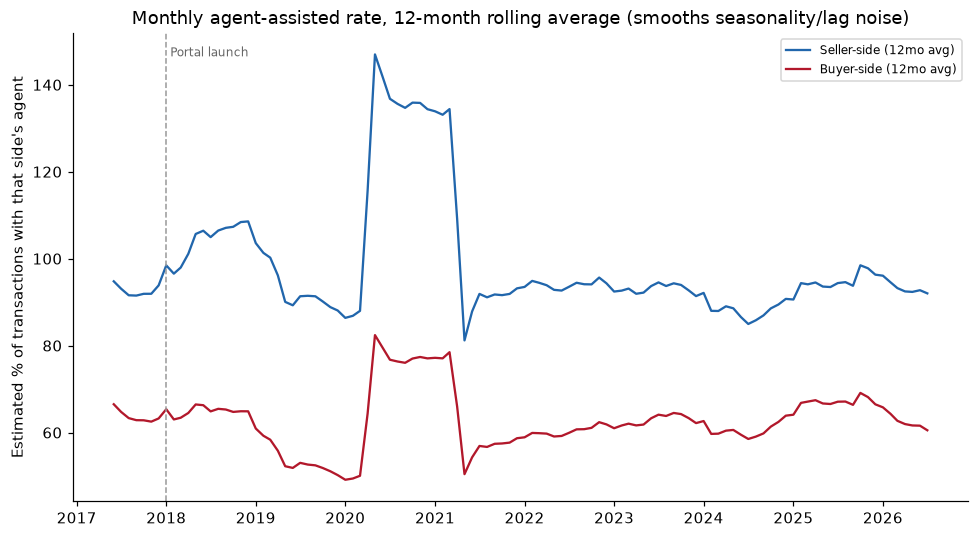

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(monthly.index, monthly["seller_agent_assisted_rate_ma12"] * 100, color="#2166ac", label="Seller-side (12mo avg)")
ax.plot(monthly.index, monthly["buyer_agent_assisted_rate_ma12"] * 100, color="#b2182b", label="Buyer-side (12mo avg)")
ax.axvline(PORTAL_LAUNCH, color="#999999", linestyle="--", linewidth=1)
ax.text(PORTAL_LAUNCH, ax.get_ylim()[1] * 0.98, " Portal launch", fontsize=8, color="#666666", va="top")
ax.set_title("Monthly agent-assisted rate, 12-month rolling average (smooths seasonality/lag noise)")
ax.set_ylabel("Estimated % of transactions with that side's agent")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT_CHARTS / "01_monthly_rolling_engagement.png")
plt.show()

Smoothed view. No jump at launch. Base series for everything below.

---
## Objective 1: Is the portal helpful?

**Short answer:** self-service flat since 2017 (~9-10% sellers, ~35-40% buyers).
Worth a look: real spike 2019-2020, gone by 2021. Not COVID.

### Self-service ("DIY") rate

`1 - agent_assisted_rate` = no agent on that side.

**Lag problem:** CEA logs deal when agreed. HDB registers ~2 months later
(HDB says 8-10 weeks). Same month, different batches. Raw rate can go >100%.
Fix: shift CEA numbers forward, find best-matching shift.

In [7]:
lag_candidates = range(0, 5)
lag_scores = []
for lag in lag_candidates:
    s_shift = monthly["seller_agent_txns"].shift(-lag)
    valid = s_shift.notna() & monthly["total_transactions"].notna()
    corr = np.corrcoef(s_shift[valid], monthly["total_transactions"][valid])[0, 1]
    rate = s_shift / monthly["total_transactions"]
    lag_scores.append({"lag_months": lag, "corr_with_total": corr, "rate_std": rate.std()})
lag_scores = pd.DataFrame(lag_scores).set_index("lag_months")
print("Lag search:")
print(lag_scores.round(3))

BEST_LAG = int(lag_scores["corr_with_total"].idxmax())
print(f"-> Using a {BEST_LAG}-month lag correction.")

Lag search:
            corr_with_total  rate_std
lag_months                           
0                     0.430     0.473
1                     0.532     0.318
2                     0.762     0.185
3                     0.511     0.508
4                     0.304     0.643
-> Using a 2-month lag correction.


2 months. Matches HDB's own stated time. Not just a curve fit.

In [8]:
lagged = pd.DataFrame({
    "total": monthly["total_transactions"],
    "seller_agent_txns_lag": monthly["seller_agent_txns"].shift(-BEST_LAG),
    "buyer_agent_txns_lag": monthly["buyer_agent_txns"].shift(-BEST_LAG),
}).dropna()
lagged["year"] = lagged.index.year

diy_annual = lagged.groupby("year").agg(
    total=("total", "sum"),
    seller_agent_txns_lag=("seller_agent_txns_lag", "sum"),
    buyer_agent_txns_lag=("buyer_agent_txns_lag", "sum"),
)
diy_annual["seller_diy_rate"] = 1 - diy_annual["seller_agent_txns_lag"] / diy_annual["total"]
diy_annual["buyer_diy_rate"] = 1 - diy_annual["buyer_agent_txns_lag"] / diy_annual["total"]
# Overall/blended rate -- one number to summarise both sides, same idea as
# monthly["avg_agent_assisted_rate"] above (simple average of the two sides).
diy_annual["avg_diy_rate"] = (diy_annual["seller_diy_rate"] + diy_annual["buyer_diy_rate"]) / 2
diy_annual.to_csv(OUT_DATA / "diy_rate.csv")

print("Lag-corrected yearly DIY rate:")
diy_annual[["seller_diy_rate", "buyer_diy_rate", "avg_diy_rate"]].round(3)

Lag-corrected yearly DIY rate:


,seller_diy_rate,buyer_diy_rate,avg_diy_rate
year,,,
2017,0.074,0.394,0.234
2018,-0.025,0.401,0.188
2019,0.106,0.491,0.298
2020,0.096,0.456,0.276
2021,0.068,0.411,0.240
2022,0.078,0.387,0.233
2023,0.113,0.398,0.255
2024,0.077,0.347,0.212
2025,0.095,0.384,0.239


2018 excluded — noisy launch year, seller rate even goes negative. 2026 excluded — partial year.

In [9]:
diy_trend = diy_annual.loc[[y for y in diy_annual.index if y not in (2018, 2026)]]
print("Is the DIY rate actually going up over time?")
diy_trend_results = {}
for col in ["seller_diy_rate", "buyer_diy_rate", "avg_diy_rate"]:
    slope, intercept, r, p, se = stats.linregress(diy_trend.index.values.astype(float), diy_trend[col].values)
    diy_trend_results[col] = {"slope_pp_per_year": slope * 100, "r2": r ** 2, "p_value": p}
    verdict = "a real increase" if (p < 0.05 and slope > 0) else \
              "a real decrease" if (p < 0.05 and slope < 0) else \
              "not a real trend (could just be noise)"
    print(f"  {col}: {slope*100:+.2f} pp/year, p={p:.3f} -> {verdict}")

Is the DIY rate actually going up over time?
  seller_diy_rate: +0.09 pp/year, p=0.721 -> not a real trend (could just be noise)
  buyer_diy_rate: -0.96 pp/year, p=0.140 -> not a real trend (could just be noise)
  avg_diy_rate: -0.44 pp/year, p=0.294 -> not a real trend (could just be noise)


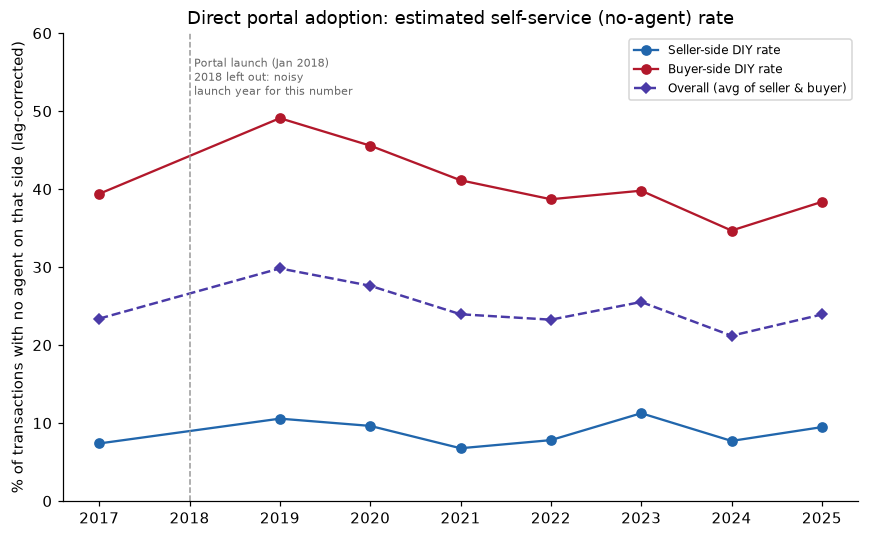

In [10]:
DIY_COMPLETE = diy_annual.loc[[y for y in diy_annual.index if y not in (2018, 2026)]]
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(DIY_COMPLETE.index, DIY_COMPLETE["seller_diy_rate"] * 100, marker="o", color="#2166ac", label="Seller-side DIY rate")
ax.plot(DIY_COMPLETE.index, DIY_COMPLETE["buyer_diy_rate"] * 100, marker="o", color="#b2182b", label="Buyer-side DIY rate")
ax.plot(DIY_COMPLETE.index, DIY_COMPLETE["avg_diy_rate"] * 100, marker="D", markersize=5, color="#4a3aa7",
        linestyle="--", linewidth=1.6, label="Overall (avg of seller & buyer)")
ax.axvline(2018, color="#999999", linestyle="--", linewidth=1)
ax.text(2018.05, 0.95, "Portal launch (Jan 2018)\n2018 left out: noisy\nlaunch year for this number",
        transform=ax.get_xaxis_transform(), fontsize=7.5, color="#666666", va="top")
ax.set_title("Direct portal adoption: estimated self-service (no-agent) rate")
ax.set_ylabel("% of transactions with no agent on that side (lag-corrected)")
ax.set_ylim(0, 60)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT_CHARTS / "02_diy_rate.png")
plt.show()

Buyers self-serve way more than sellers — browsing alone is easier than selling alone.
Flat overall, except 2019-2020 bulge. Next up.

### Was 2019-2020 bulge the portal?

Seller: 7.4 → 10.6 → 9.6 → 6.8%. Buyer: 39.4 → 49.1 → 45.6 → 41.1%.
Jumps, then drops back by 2021. Noise or portal? Check below.

**Bigger than normal noise?** Only 8 clean years. Check every possible 2-year combo, see how extreme 2019+2020 is.

In [11]:
diy_years = list(diy_trend.index)  # the 8 clean years: 2017, 2019-2025
all_pairs = list(combinations(diy_years, 2))  # every possible way to pick 2 of the 8

bulge_significance = {}
for col in ["seller_diy_rate", "buyer_diy_rate"]:
    vals = diy_trend[col]
    actual_mean = vals.loc[[2019, 2020]].mean()
    pair_means = [vals.loc[list(p)].mean() for p in all_pairs]
    n_as_extreme = sum(1 for m in pair_means if m >= actual_mean)
    rank = sorted(pair_means, reverse=True).index(actual_mean) + 1
    p_exact = n_as_extreme / len(all_pairs)
    bulge_significance[col] = {"rank": rank, "n_pairs": len(all_pairs), "p_exact": p_exact}
    print(f"{col}: rank {rank} of {len(all_pairs)} possible 2-year picks, p={p_exact:.3f}")

seller_diy_rate: rank 4 of 28 possible 2-year picks, p=0.143
buyer_diy_rate: rank 1 of 28 possible 2-year picks, p=0.036


**Buyer: real.** Rank 1 of 28, p≈0.04 — most extreme pick possible.
**Seller: could be noise.** Rank 4 of 28, p≈0.14. From here, buyer-side story only.

**COVID?** HDB paused registrations Apr-May 2020, cleared backlog Jun-Jul. Real glitch, temporary. Not a behaviour change.

In [12]:
covid_window = monthly.loc["2019-06":"2021-06", ["total_transactions", "seller_agent_assisted_rate", "buyer_agent_assisted_rate"]]
covid_window.loc["2020-02":"2020-08"].round(3)

,total_transactions,seller_agent_assisted_rate,buyer_agent_assisted_rate
month_start,,,
2020-02-01,1661,0.951,0.554
2020-03-01,1937,0.895,0.504
2020-04-01,424,4.002,2.090
2020-05-01,363,4.394,2.526
2020-06-01,2438,0.160,0.099
2020-07-01,2456,0.292,0.177
2020-08-01,2426,0.864,0.508


In [13]:
# What if we simply drop the 4 disrupted months (Apr-Jul: the crash plus the
# backlog-clearing rebound) from 2020's yearly DIY rate, instead of including them?
full_2020 = lagged.loc["2020-01":"2020-12"]
seller_full = 1 - full_2020["seller_agent_txns_lag"].sum() / full_2020["total"].sum()
buyer_full = 1 - full_2020["buyer_agent_txns_lag"].sum() / full_2020["total"].sum()

ex_covid = full_2020.drop(lagged.loc["2020-04":"2020-07"].index)
seller_ex = 1 - ex_covid["seller_agent_txns_lag"].sum() / ex_covid["total"].sum()
buyer_ex = 1 - ex_covid["buyer_agent_txns_lag"].sum() / ex_covid["total"].sum()

print(f"2020 DIY rate, full year:            seller={seller_full*100:.2f}%  buyer={buyer_full*100:.2f}%")
print(f"2020 DIY rate, without Apr-Jul:       seller={seller_ex*100:.2f}%  buyer={buyer_ex*100:.2f}%")
print("Barely changes -- and 2019's bulge is even bigger, a year before COVID existed.")

2020 DIY rate, full year:            seller=9.63%  buyer=45.57%
2020 DIY rate, without Apr-Jul:       seller=10.80%  buyer=46.09%
Barely changes -- and 2019's bulge is even bigger, a year before COVID existed.


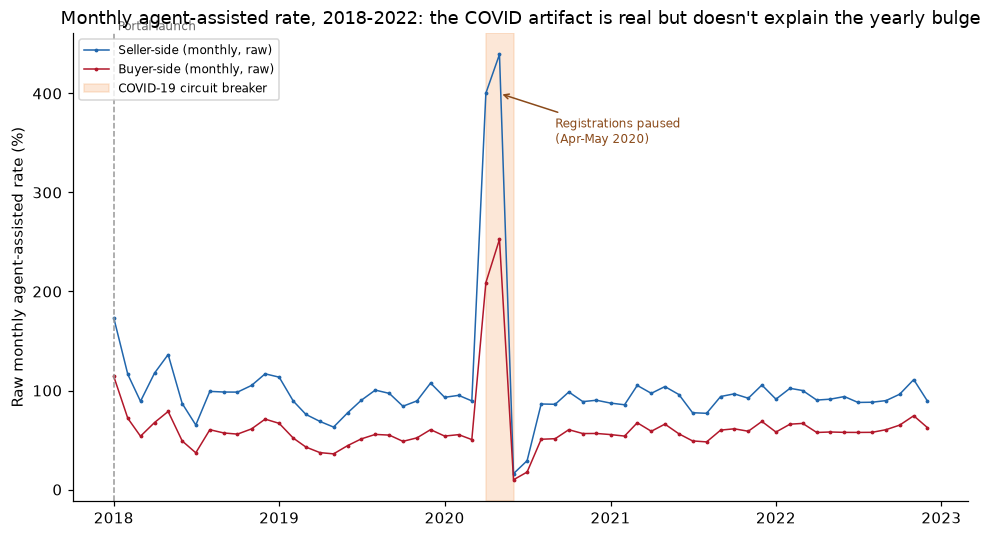

In [14]:
window = monthly.loc["2018-01":"2022-12"]
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(window.index, window["seller_agent_assisted_rate"] * 100, color="#2166ac", linewidth=1, marker=".", markersize=3, label="Seller-side (monthly, raw)")
ax.plot(window.index, window["buyer_agent_assisted_rate"] * 100, color="#b2182b", linewidth=1, marker=".", markersize=3, label="Buyer-side (monthly, raw)")
ax.axvspan(pd.Timestamp("2020-04-01"), pd.Timestamp("2020-06-01"), color="#f4a261", alpha=0.25, label="COVID-19 circuit breaker")
ax.axvline(PORTAL_LAUNCH, color="#999999", linestyle="--", linewidth=1)
ax.text(PORTAL_LAUNCH, ax.get_ylim()[1], " Portal launch", fontsize=8, color="#666666", va="bottom")
ax.annotate("Registrations paused\n(Apr-May 2020)", xy=(pd.Timestamp("2020-05-01"), 400),
            xytext=(pd.Timestamp("2020-09-01"), 350), fontsize=8, color="#8a4a1a",
            arrowprops=dict(arrowstyle="->", color="#8a4a1a", lw=1))
ax.set_title("Monthly agent-assisted rate, 2018-2022: the COVID artifact is real but doesn't explain the yearly bulge")
ax.set_ylabel("Raw monthly agent-assisted rate (%)")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig(OUT_CHARTS / "03_dip_attribution.png")
plt.show()

Spike >400% then crash <30% = paperwork backlog, not agent-use change.
**Ruled out.** Barely moves annual number. Can't touch 2019 at all.

**Our lag fix wrong for this window?** Re-ran lag search on just 2018-2021.

In [15]:
def lag_search(df, y0, y1):
    sub = df.loc[f"{y0}-01":f"{y1}-12"]
    scores = []
    for lag in range(0, 5):
        s_shift = sub["seller_agent_txns"].shift(-lag)
        valid = s_shift.notna() & sub["total_transactions"].notna()
        corr = np.corrcoef(s_shift[valid], sub["total_transactions"][valid])[0, 1]
        scores.append({"lag_months": lag, "corr": corr})
    return pd.DataFrame(scores).set_index("lag_months")


dip_window_scores = lag_search(monthly, 2018, 2021)
post_dip_scores = lag_search(monthly, 2022, 2025)
best_dip_lag = int(dip_window_scores["corr"].idxmax())
best_post_lag = int(post_dip_scores["corr"].idxmax())

print(f"Lag fit, 2018-2021: best lag = {best_dip_lag} months, corr = {dip_window_scores['corr'].max():.3f}")
print(f"Lag fit, 2022-2025: best lag = {best_post_lag} months, corr = {post_dip_scores['corr'].max():.3f}")
print(f"(Full period: best lag = {BEST_LAG} months, corr = {lag_scores['corr_with_total'].max():.3f})")

Lag fit, 2018-2021: best lag = 2 months, corr = 0.825
Lag fit, 2022-2025: best lag = 2 months, corr = 0.630
(Full period: best lag = 2 months, corr = 0.762)


**Ruled out too.** Fits just as well — actually better — in this window. Not a lag artifact.

**One more idea: fewer agents in 2019, not more DIY?**
2018 had an unusually big wave of new agents (3,257 vs ~1,500-1,800 normal). If many quit fast,
that alone shrinks 2019's agent count.

In [16]:
agent_years = cea.groupby("salesperson_reg_num")["year"].apply(set)

entrants_2018 = [reg for reg, yrs in agent_years.items() if min(yrs) == 2018]
retained_2019 = sum(1 for reg in entrants_2018 if 2019 in agent_years[reg])
print(f"2018 new agents: {len(entrants_2018):,}. Still active in 2019: {retained_2019/len(entrants_2018)*100:.1f}%.")

entrants_2022 = [reg for reg, yrs in agent_years.items() if min(yrs) == 2022]
retained_2023 = sum(1 for reg in entrants_2022 if 2023 in agent_years[reg])
print(f"Normal year for comparison (2022 entrants): {retained_2023/len(entrants_2022)*100:.1f}% retained.")

one_and_done = set(entrants_2018) - {reg for reg in entrants_2018 if 2019 in agent_years[reg]}
deals_2018_one_and_done = cea[(cea["year"] == 2018) & (cea["salesperson_reg_num"].isin(one_and_done))].shape[0]
deals_2018_total = cea[cea["year"] == 2018].shape[0]
print(f"Deals done by agents who never came back: {deals_2018_one_and_done/deals_2018_total*100:.1f}% of 2018's total.")

one_and_done_coverage = {}
for role in ["SELLER", "BUYER"]:
    role_2018 = cea[(cea["year"] == 2018) & (cea["represented"] == role)]
    role_one_and_done = role_2018[role_2018["salesperson_reg_num"].isin(one_and_done)]
    role_2019_count = cea[(cea["year"] == 2019) & (cea["represented"] == role)].shape[0]
    role_shortfall = len(role_2018) - role_2019_count
    coverage_pct = len(role_one_and_done) / role_shortfall * 100 if role_shortfall else float("nan")
    one_and_done_coverage[role] = coverage_pct
    print(f"{role}: covers {coverage_pct:.0f}% of the 2018->2019 agent-deal drop.")

2018 new agents: 3,257. Still active in 2019: 42.2%.
Normal year for comparison (2022 entrants): 52.6% retained.
Deals done by agents who never came back: 7.5% of 2018's total.
SELLER: covers 53% of the 2018->2019 agent-deal drop.
BUYER: covers 49% of the 2018->2019 agent-deal drop.


**Partly true, not the whole story.** 2018 retention lower (42% vs 53% normal). Explains
about half the drop, evenly both sides. Doesn't explain buyer-vs-seller split. Rest = something else.

### So, was it the portal?

COVID: ruled out. Lag fix: ruled out. Fewer agents: covers half, not all.
**Buyer side: likely portal.** Best explanation left, not fully proven (no usage data).
**Seller side: not enough evidence either way.**

### Did the market itself speed up?

*(Not in slides, kept short.)* Maybe more transactions overall, even without more self-service.
Check actual volume vs. pre-2018 trend, using history back to 1990.

In [17]:
history_files = [
    "Resale Flat Prices (Based on Approval Date), 1990 - 1999.csv",
    "Resale Flat Prices (Based on Approval Date), 2000 - Feb 2012.csv",
    "Resale Flat Prices (Based on Registration Date), From Mar 2012 to Dec 2014.csv",
    "Resale Flat Prices (Based on Registration Date), From Jan 2015 to Dec 2016.csv",
]
history_frames = [
    pd.read_csv(DATA_DIR / "ResaleFlatPrices" / f, usecols=["month"]).assign(
        month=lambda d: pd.to_datetime(d["month"], format="%Y-%m")
    )
    for f in history_files
]
history_frames.append(resale[["month"]])
full_history = pd.concat(history_frames, ignore_index=True)
volume_monthly = full_history.groupby("month").size().sort_index()
volume_monthly = volume_monthly[volume_monthly.index <= "2025-12-01"]  # drop partial 2026
volume_monthly.to_csv(OUT_DATA / "long_run_volume_monthly.csv", header=["transactions"])
print(f"{len(volume_monthly)} months assembled, {volume_monthly.index.min():%Y-%m} to {volume_monthly.index.max():%Y-%m}")

432 months assembled, 1990-01 to 2025-12


In [18]:
def counterfactual_test(series, baseline_start, baseline_end, horizon_start, horizon_months):
    """Fit a straight-line trend on [baseline_start, baseline_end], extend it forward
    horizon_months from horizon_start, and check whether actual values move away from
    that extension."""
    baseline = series.loc[baseline_start:baseline_end]
    x = np.arange(len(baseline))
    slope, intercept, r, _p_trend, _se = stats.linregress(x, baseline.values)
    future_idx = pd.date_range(horizon_start, periods=horizon_months, freq="MS")
    x_future = np.arange(len(baseline), len(baseline) + len(future_idx))
    predicted = intercept + slope * x_future
    actual = series.reindex(future_idx).values
    resid = actual - predicted
    _t_stat, p_resid = stats.ttest_1samp(resid, 0)
    return {
        "baseline_months": len(baseline), "baseline_slope_per_month": slope, "baseline_r2": r ** 2,
        "horizon_months": horizon_months, "actual_vs_counterfactual_pct": resid.mean() / predicted.mean(),
        "p_value": p_resid,
    }


break_test = counterfactual_test(volume_monthly, "2013-01-01", "2017-12-01", "2018-01-01", 24)
print(f"2018-2019 actual vs. pre-2018 trend extended forward: {break_test['actual_vs_counterfactual_pct']:+.1%}, "
      f"p={break_test['p_value']:.3f} -> no real difference from the existing trend.")

2018-2019 actual vs. pre-2018 trend extended forward: -2.0%, p=0.565 -> no real difference from the existing trend.


In [19]:
robustness = pd.DataFrame([
    counterfactual_test(volume_monthly, start, "2017-12-01", "2018-01-01", 24)
    for start in ["2013-01-01", "2014-01-01", "2015-01-01", "2016-01-01"]
], index=["2013-2017", "2014-2017", "2015-2017", "2016-2017"])
print("Same result across different baseline windows:")
robustness[["actual_vs_counterfactual_pct", "p_value"]].round(3)

Same result across different baseline windows:


,actual_vs_counterfactual_pct,p_value
2013-2017,-0.020,0.565
2014-2017,-0.059,0.089
2015-2017,-0.058,0.093
2016-2017,-0.068,0.048


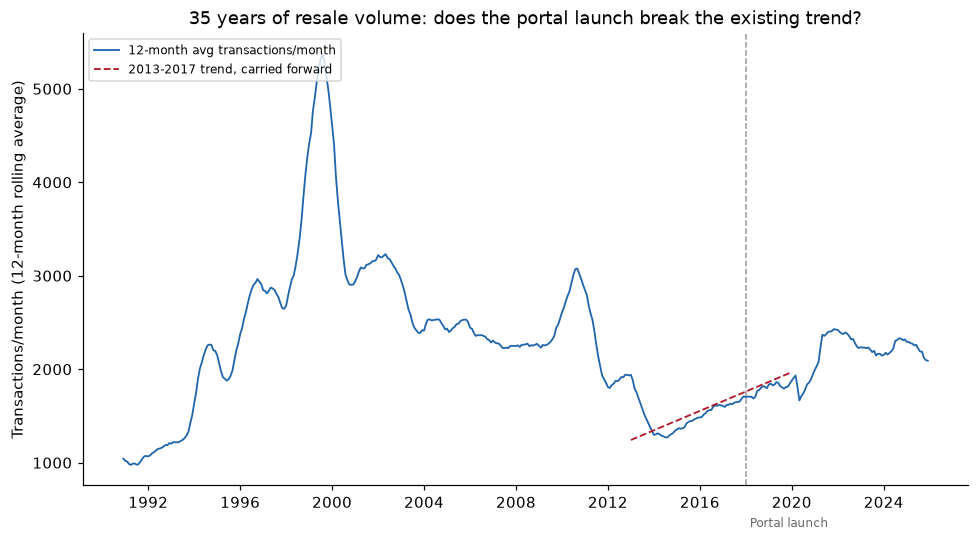

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(volume_monthly.index, volume_monthly.rolling(12).mean(), color="#2166ac", linewidth=1.2, label="12-month avg transactions/month")
baseline = volume_monthly.loc["2013-01-01":"2017-12-01"]
x = np.arange(len(baseline))
slope, intercept, _, _, _ = stats.linregress(x, baseline.values)
extrap_idx = pd.date_range("2013-01-01", "2019-12-01", freq="MS")
extrap_x = np.arange(len(extrap_idx))
ax.plot(extrap_idx, intercept + slope * extrap_x, color="#b2182b", linewidth=1.2, linestyle="--",
        label="2013-2017 trend, carried forward")
ax.axvline(PORTAL_LAUNCH, color="#999999", linestyle="--", linewidth=1)
ax.text(PORTAL_LAUNCH, ax.get_ylim()[1] * 0.05, " Portal launch", fontsize=8, color="#666666", va="bottom")
ax.set_title("35 years of resale volume: does the portal launch break the existing trend?")
ax.set_ylabel("Transactions/month (12-month rolling average)")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig(OUT_CHARTS / "04_longrun_volume_structural_break.png")
plt.show()

Blue tracks dashed red closely. No jump after Jan 2018. Market kept doing its own thing.

**Objective 1 wrap-up:** self-service flat. Market didn't speed up. One real bump —
buyer-side, 2019-2020, likely portal. Only place evidence points to the portal doing something.

---
## Objective 2: Did it hurt agents' business?

**Short answer:** business held up. Workforce +22% since 2017. Productivity and
market share flat. Exception: churn turned negative 2023-2024 — more leaving than joining, first time.

In [21]:
annual = monthly.groupby(monthly.index.year).agg(
    total_transactions=("total_transactions", "sum"),
    seller_agent_txns=("seller_agent_txns", "sum"),
    buyer_agent_txns=("buyer_agent_txns", "sum"),
)
# Active agents per YEAR must be recomputed from raw data (nunique doesn't sum across months).
annual["active_agents"] = cea.groupby("year")["salesperson_reg_num"].nunique()
annual["seller_agent_assisted_rate"] = annual["seller_agent_txns"] / annual["total_transactions"]
annual["buyer_agent_assisted_rate"] = annual["buyer_agent_txns"] / annual["total_transactions"]
annual["avg_agent_assisted_rate"] = (annual["seller_agent_assisted_rate"] + annual["buyer_agent_assisted_rate"]) / 2
annual["deals_per_agent"] = (annual["seller_agent_txns"] + annual["buyer_agent_txns"]) / annual["active_agents"]
annual.index.name = "year"
annual.to_csv(OUT_DATA / "annual_metrics.csv")
annual[["total_transactions", "seller_agent_txns", "buyer_agent_txns", "active_agents",
        "seller_agent_assisted_rate", "buyer_agent_assisted_rate", "deals_per_agent"]] \
    .round({"seller_agent_assisted_rate": 3, "buyer_agent_assisted_rate": 3, "deals_per_agent": 2})

,total_transactions,seller_agent_txns,buyer_agent_txns,active_agents,seller_agent_assisted_rate,buyer_agent_assisted_rate,deals_per_agent
year,,,,,,,
2017,20509,18670,12492,8673,0.910,0.609,3.59
2018,21561,22405,13269,9128,1.039,0.615,3.91
2019,22186,19407,11054,8190,0.875,0.498,3.72
2020,23333,20421,12103,8500,0.875,0.519,3.83
2021,29087,26976,17002,10156,0.927,0.585,4.33
2022,26720,25122,16484,10523,0.940,0.617,3.95
2023,25754,23326,15865,10510,0.906,0.616,3.73
2024,27832,25038,17609,10845,0.900,0.633,3.93
2025,25085,23489,16244,10578,0.936,0.648,3.76


Raw rates >100% some years too — same lag issue. Index to 2017=100 instead of reading raw %.

In [22]:
base = annual.loc[2017]
annual["seller_agent_assisted_index"] = annual["seller_agent_assisted_rate"] / base["seller_agent_assisted_rate"] * 100
annual["buyer_agent_assisted_index"] = annual["buyer_agent_assisted_rate"] / base["buyer_agent_assisted_rate"] * 100
annual["active_agents_index"] = annual["active_agents"] / base["active_agents"] * 100
annual["deals_per_agent_index"] = annual["deals_per_agent"] / base["deals_per_agent"] * 100
annual.to_csv(OUT_DATA / "annual_metrics.csv")

YEARS_COMPLETE = annual.loc[2017:LAST_COMPLETE_YEAR]
annual[["seller_agent_assisted_index", "buyer_agent_assisted_index",
        "active_agents_index", "deals_per_agent_index"]].round(1)

,seller_agent_assisted_index,buyer_agent_assisted_index,active_agents_index,deals_per_agent_index
year,,,,
2017,100.0,100.0,100.0,100.0
2018,114.2,101.0,105.2,108.8
2019,96.1,81.8,94.4,103.5
2020,96.1,85.2,98.0,106.5
2021,101.9,96.0,117.1,120.5
2022,103.3,101.3,121.3,110.0
2023,99.5,101.1,121.2,103.8
2024,98.8,103.9,125.0,109.4
2025,102.9,106.3,122.0,104.5


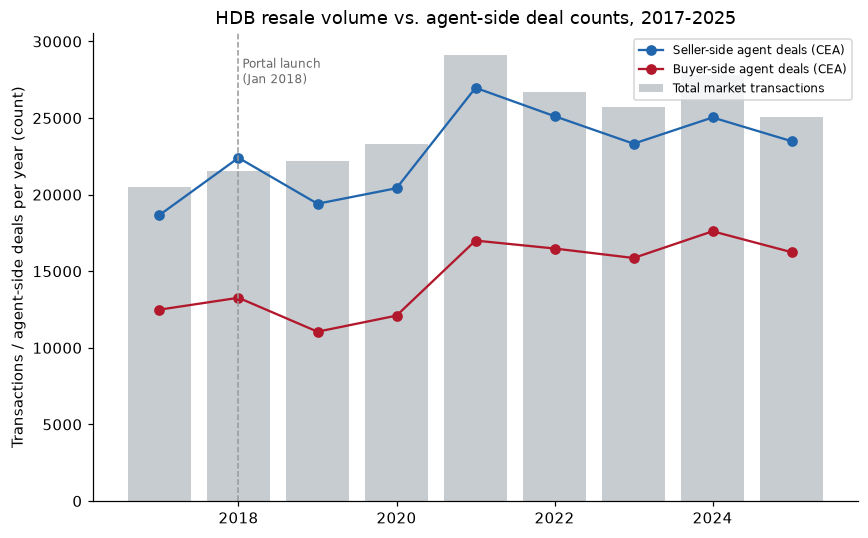

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(YEARS_COMPLETE.index, YEARS_COMPLETE["total_transactions"], color="#c7ccd1", label="Total market transactions")
ax.plot(YEARS_COMPLETE.index, YEARS_COMPLETE["seller_agent_txns"], marker="o", color="#2166ac", label="Seller-side agent deals (CEA)")
ax.plot(YEARS_COMPLETE.index, YEARS_COMPLETE["buyer_agent_txns"], marker="o", color="#b2182b", label="Buyer-side agent deals (CEA)")
annotate_launch(ax)
ax.set_title("HDB resale volume vs. agent-side deal counts, 2017-2025")
ax.set_ylabel("Transactions / agent-side deals per year (count)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT_CHARTS / "05_volume_vs_agent_deals.png")
plt.show()

Bars and lines move together. Agents keeping pace with market. (Lines don't need to sum
to the bar — most deals have agents on *both* sides, so seller + buyer double-counts.)

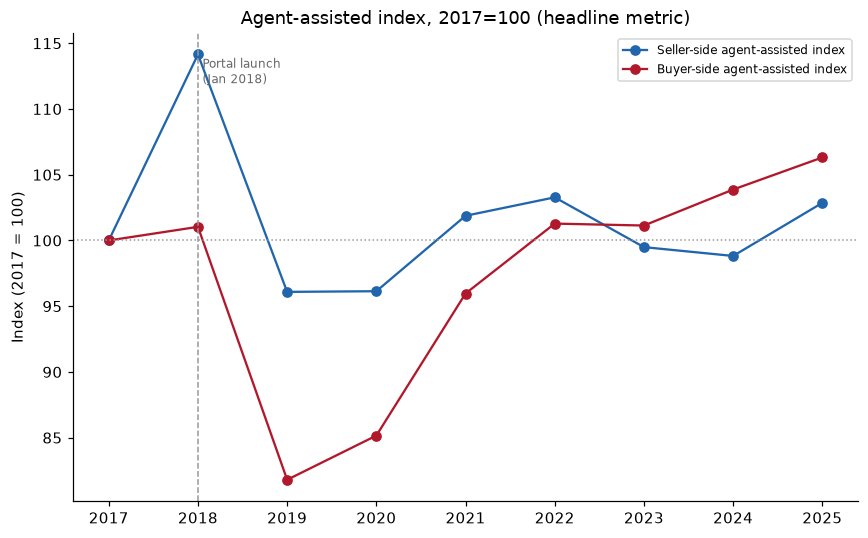

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(YEARS_COMPLETE.index, YEARS_COMPLETE["seller_agent_assisted_index"], marker="o", color="#2166ac", label="Seller-side agent-assisted index")
ax.plot(YEARS_COMPLETE.index, YEARS_COMPLETE["buyer_agent_assisted_index"], marker="o", color="#b2182b", label="Buyer-side agent-assisted index")
ax.axhline(100, color="#999999", linewidth=1, linestyle=":")
annotate_launch(ax)
ax.set_title("Agent-assisted index, 2017=100 (headline metric)")
ax.set_ylabel("Index (2017 = 100)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT_CHARTS / "06_engagement_index.png")
plt.show()

Both lines at/above 100 by 2025. Market share stable. Temporary dip 2019-2020 (same bulge as Obj 1). No sustained decline.

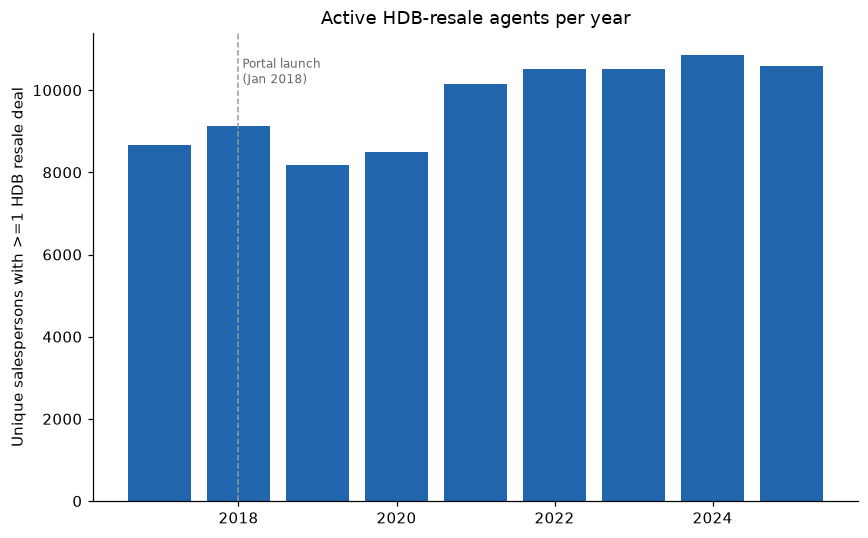

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(YEARS_COMPLETE.index, YEARS_COMPLETE["active_agents"], color="#2166ac")
annotate_launch(ax)
ax.set_title("Active HDB-resale agents per year")
ax.set_ylabel("Unique salespersons with >=1 HDB resale deal")
fig.tight_layout()
fig.savefig(OUT_CHARTS / "07_active_agents.png")
plt.show()

Agent count keeps growing since 2017. No sign portal pushing agents out.

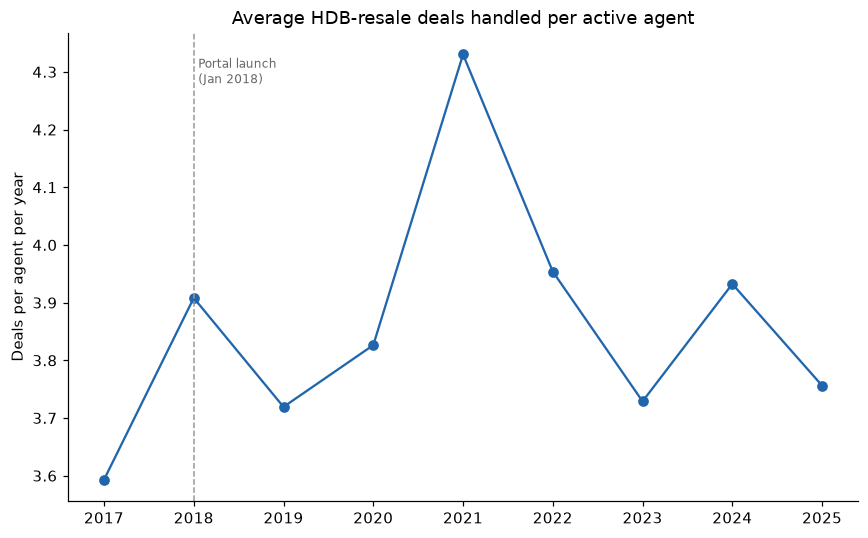

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(YEARS_COMPLETE.index, YEARS_COMPLETE["deals_per_agent"], marker="o", color="#2166ac")
annotate_launch(ax)
ax.set_title("Average HDB-resale deals handled per active agent")
ax.set_ylabel("Deals per agent per year")
fig.tight_layout()
fig.savefig(OUT_CHARTS / "08_deals_per_agent.png")
plt.show()

Same workload as 2017, bump in 2021 (resale boom). No sign of less work from self-service.

In [27]:
agent_span = cea.groupby("salesperson_reg_num")["year"].agg(["min", "max"]).rename(
    columns={"min": "first_year", "max": "last_year"}
)
years = sorted(cea["year"].unique())
last_full_year = min(LAST_COMPLETE_YEAR, max(years))

entrants = agent_span[agent_span["first_year"] > 2017].groupby("first_year").size()
# "Left in year Y" = last active in year Y, confirmed by no deals in any later year
# through last_full_year. Right-censored -- the most recent year can never show a
# real "left" count, so it's marked NaN rather than 0.
exits = agent_span[agent_span["last_year"] < last_full_year].groupby("last_year").size()

churn = pd.DataFrame({"new_entrants": entrants, "exits": exits})
churn = churn.reindex(range(2017, last_full_year + 1))
churn.loc[2017, "new_entrants"] = np.nan
churn.loc[last_full_year, "exits"] = np.nan
churn["net_change"] = churn["new_entrants"] - churn["exits"]
churn.index.name = "year"
churn.to_csv(OUT_DATA / "agent_churn.csv")
churn

,new_entrants,exits,net_change
year,,,
2017,NaN,1005.0,NaN
2018,3257.0,1079.0,2178.0
2019,1794.0,829.0,965.0
2020,1520.0,798.0,722.0
2021,1743.0,1228.0,515.0
2022,1827.0,1562.0,265.0
2023,1629.0,2004.0,-375.0
2024,1481.0,2823.0,-1342.0
2025,1282.0,NaN,NaN


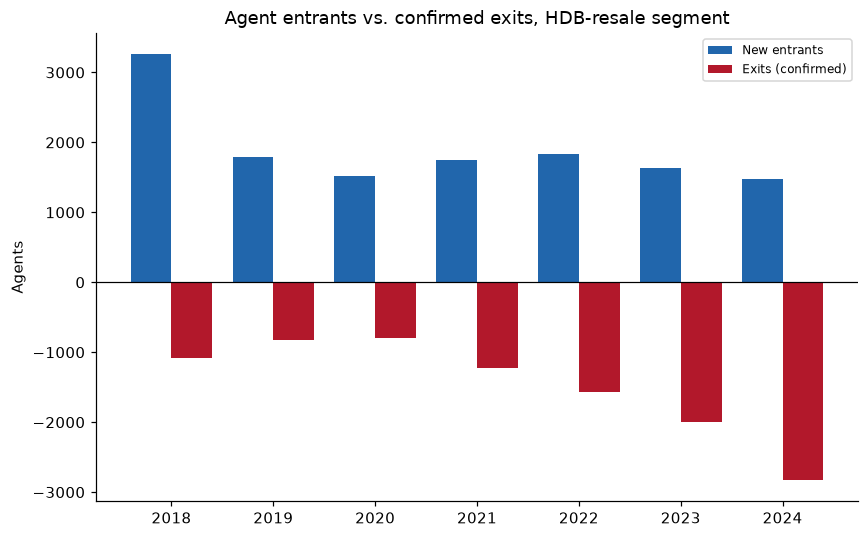

In [28]:
churn_plot = churn.loc[2018:2024]
fig, ax = plt.subplots(figsize=(8, 5))
width = 0.4
x = np.arange(len(churn_plot))
ax.bar(x - width / 2, churn_plot["new_entrants"], width, color="#2166ac", label="New entrants")
ax.bar(x + width / 2, -churn_plot["exits"], width, color="#b2182b", label="Exits (confirmed)")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(churn_plot.index)
ax.set_title("Agent entrants vs. confirmed exits, HDB-resale segment")
ax.set_ylabel("Agents")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT_CHARTS / "09_agent_churn.png")
plt.show()

New agents beat exits most years — until 2023-2024, exits win first time.

In [29]:
def top_decile_share(reg_nums: pd.Series) -> float:
    """Share of that year's HDB-resale agent-side deals done by the busiest 10% of agents."""
    counts = reg_nums.value_counts().sort_values(ascending=False)
    n_top = max(1, int(np.ceil(len(counts) * 0.10)))
    return counts.iloc[:n_top].sum() / counts.sum()


def gini(counts: np.ndarray) -> float:
    """Gini coefficient of deals-per-agent (0 = perfectly even, 1 = as uneven as possible)."""
    x = np.sort(counts)
    n = len(x)
    cum = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cum) / cum[-1]) / n


concentration = cea.groupby("year")["salesperson_reg_num"].agg(
    top_decile_share=top_decile_share,
    gini=lambda s: gini(s.value_counts().values),
)
concentration.to_csv(OUT_DATA / "agent_concentration.csv")
concentration.round(3)

,top_decile_share,gini
year,,
2017,0.437,0.531
2018,0.446,0.546
2019,0.444,0.540
2020,0.459,0.551
2021,0.445,0.550
2022,0.430,0.534
2023,0.429,0.531
2024,0.442,0.542
2025,0.436,0.535


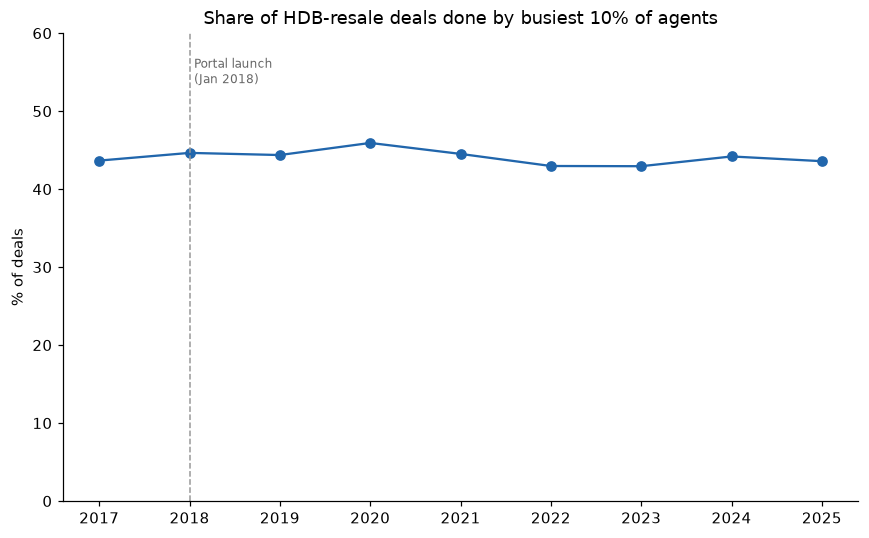

In [30]:
CONC_COMPLETE = concentration.loc[2017:LAST_COMPLETE_YEAR]
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(CONC_COMPLETE.index, CONC_COMPLETE["top_decile_share"] * 100, marker="o", color="#2166ac")
annotate_launch(ax)
ax.set_title("Share of HDB-resale deals done by busiest 10% of agents")
ax.set_ylabel("% of deals")
ax.set_ylim(0, 60)
fig.tight_layout()
fig.savefig(OUT_CHARTS / "10_concentration.png")
plt.show()

Top 10% hold ~40-46% of deals every year. No consolidating.

**Objective 2 wrap-up:** workforce grew, workload steady, concentration flat. Churn flip
2023-2024 = watch this. Years after launch, doesn't track self-service numbers. Likely industry-wide, not portal.

---
## Objective 3: What changed overall?

**Short answer:** biggest change = unrelated to portal. Resale prices +53%
(2017→2025), COVID-era cycle. Self-service stayed niche, agent workforce grew with market.

In [31]:
resale["price_per_sqm"] = resale["resale_price"] / resale["floor_area_sqm"]
price_annual = resale.groupby("year").agg(
    median_resale_price=("resale_price", "median"),
    median_price_per_sqm=("price_per_sqm", "median"),
)
price_annual.to_csv(OUT_DATA / "price_context.csv")
price_annual.round(0)

,median_resale_price,median_price_per_sqm
year,,
2017,410000.0,4282.0
2018,408000.0,4209.0
2019,400000.0,4176.0
2020,425000.0,4356.0
2021,483000.0,4916.0
2022,525000.0,5373.0
2023,550000.0,5709.0
2024,590000.0,6098.0
2025,628000.0,6500.0


Median price: $410k (2017) → $628k (2025). COVID-era run-up, explains the 2021 volume boom
too. Bigger, pricier market — not faster (Obj 1 already showed no launch jump). Self-service small
slice. Workforce grew with market. Concentration held. Only new thing: churn negative 2023-2024, no
clear portal link.

---
## Objective 4: Does adoption differ by town?

**Short answer:** yes, a lot. Self-service: 6.3-13.4% sellers, 31-68% buyers
across towns. Way more spread than the flat national trend. Smaller towns
self-serve more. Maybe the biggest finding here — national average hides real area differences.

In [32]:
print("CEA town coverage:", cea['town'].nunique(), "towns,", (cea['town'] == '-').sum(), "placeholder rows")
print("ResaleFlatPrices town coverage:", resale['town'].nunique(), "towns")
print("Labels match exactly:", set(cea['town'].unique()) == set(resale['town'].unique()))

CEA town coverage: 26 towns, 0 placeholder rows
ResaleFlatPrices town coverage: 26 towns
Labels match exactly: True


Same DIY method as Obj 1, grouped by town not year. Pooling 2019-2025 for stable numbers on smaller towns.

In [33]:
town_total = resale.groupby(["town", "month_start"]).size().rename("total").reset_index()
town_agent = (
    cea.groupby(["town", "month_start", "represented"]).size().unstack(fill_value=0).reset_index()
    .rename(columns={"SELLER": "seller_agent_txns", "BUYER": "buyer_agent_txns"})
)
town_monthly = town_total.merge(town_agent, on=["town", "month_start"], how="left").fillna(0)
town_monthly = town_monthly.sort_values(["town", "month_start"])
town_monthly["seller_agent_txns_lag"] = town_monthly.groupby("town")["seller_agent_txns"].shift(-BEST_LAG)
town_monthly["buyer_agent_txns_lag"] = town_monthly.groupby("town")["buyer_agent_txns"].shift(-BEST_LAG)
town_monthly["year"] = town_monthly["month_start"].dt.year

town_window = town_monthly[(town_monthly["year"] >= 2019) & (town_monthly["year"] <= 2025)].dropna(
    subset=["seller_agent_txns_lag"]
)
by_town = town_window.groupby("town").agg(
    total=("total", "sum"),
    seller_lag=("seller_agent_txns_lag", "sum"),
    buyer_lag=("buyer_agent_txns_lag", "sum"),
)
by_town["seller_diy_rate"] = 1 - by_town["seller_lag"] / by_town["total"]
by_town["buyer_diy_rate"] = 1 - by_town["buyer_lag"] / by_town["total"]
by_town = by_town.sort_values("seller_diy_rate", ascending=False)
by_town.to_csv(OUT_DATA / "diy_rate_by_town.csv")
by_town[["total", "seller_diy_rate", "buyer_diy_rate"]].round(3)

,total,seller_diy_rate,buyer_diy_rate
town,,,
CENTRAL AREA,1377,0.134,0.638
BUKIT TIMAH,424,0.123,0.684
SERANGOON,3064,0.117,0.495
TOA PAYOH,5730,0.114,0.510
BISHAN,3038,0.111,0.550
BUKIT MERAH,6768,0.110,0.573
ANG MO KIO,7108,0.108,0.458
MARINE PARADE,1103,0.102,0.567
GEYLANG,4472,0.102,0.510


In [34]:
r_seller, p_seller = stats.pearsonr(by_town["seller_diy_rate"], np.log(by_town["total"]))
r_buyer, p_buyer = stats.pearsonr(by_town["buyer_diy_rate"], np.log(by_town["total"]))
print(f"DIY rate vs. town volume: seller r={r_seller:.2f} (p={p_seller:.4f}), buyer r={r_buyer:.2f} (p={p_buyer:.4f})")
print(f"Town range: seller {by_town['seller_diy_rate'].min()*100:.1f}%-{by_town['seller_diy_rate'].max()*100:.1f}%, "
      f"buyer {by_town['buyer_diy_rate'].min()*100:.1f}%-{by_town['buyer_diy_rate'].max()*100:.1f}%")

DIY rate vs. town volume: seller r=-0.61 (p=0.0010), buyer r=-0.81 (p=0.0000)
Town range: seller 6.3%-13.4%, buyer 30.7%-68.4%


Smaller/quieter towns = higher self-service. Checked it's not a fluke:

In [35]:
def town_diy_rate(df, y0, y1):
    w = df[(df["year"] >= y0) & (df["year"] <= y1)].dropna(subset=["seller_agent_txns_lag"])
    g = w.groupby("town").agg(total=("total", "sum"), seller_lag=("seller_agent_txns_lag", "sum"))
    g["seller_diy_rate"] = 1 - g["seller_lag"] / g["total"]
    return g["seller_diy_rate"]

early = town_diy_rate(town_monthly, 2019, 2021)
late = town_diy_rate(town_monthly, 2022, 2025)
rank_rho, rank_p = stats.spearmanr(early, late)
print(f"Town ranking, 2019-2021 vs 2022-2025: rho={rank_rho:.2f}, p={rank_p:.4f} -> not random, holds up over time.")

Town ranking, 2019-2021 vs 2022-2025: rho=0.68, p=0.0001 -> not random, holds up over time.


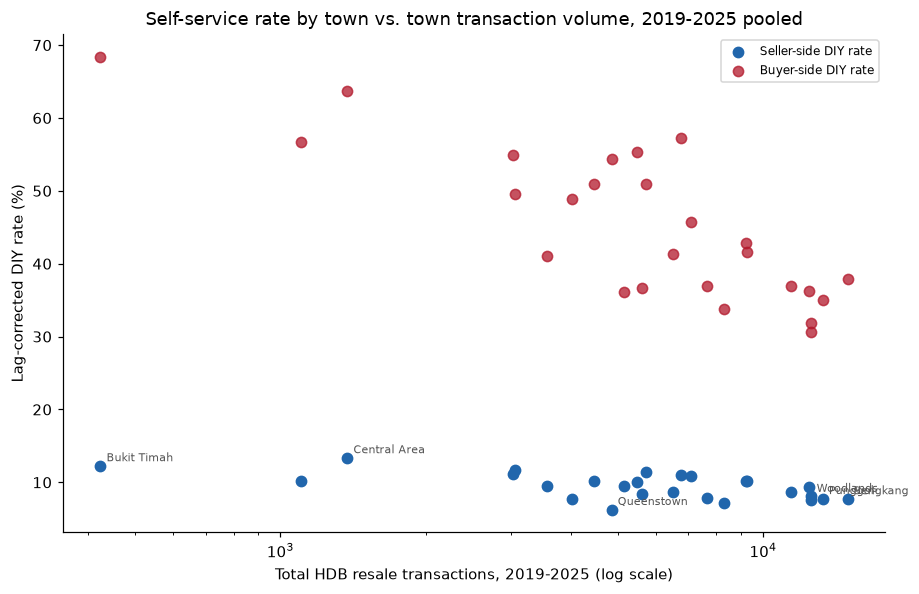

In [36]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.scatter(by_town["total"], by_town["seller_diy_rate"] * 100, color="#2166ac", s=45, label="Seller-side DIY rate", zorder=3)
ax.scatter(by_town["total"], by_town["buyer_diy_rate"] * 100, color="#b2182b", s=45, label="Buyer-side DIY rate", zorder=3, alpha=0.75)
for town in ["CENTRAL AREA", "BUKIT TIMAH", "QUEENSTOWN", "SENGKANG", "WOODLANDS", "PUNGGOL"]:
    row = by_town.loc[town]
    ax.annotate(town.title(), (row["total"], row["seller_diy_rate"] * 100), fontsize=7, color="#555555",
                xytext=(4, 3), textcoords="offset points")
ax.set_xscale("log")
ax.set_title("Self-service rate by town vs. town transaction volume, 2019-2025 pooled")
ax.set_xlabel("Total HDB resale transactions, 2019-2025 (log scale)")
ax.set_ylabel("Lag-corrected DIY rate (%)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT_CHARTS / "11_town_diy_rate.png")
plt.show()

Central Area, Bukit Timah (small, quiet) = high. Sengkang, Punggol, Woodlands (big, busy) = low. Real sloped pattern, not scatter.

**Objective 4 wrap-up:** flat national number hides real geographic differences. Smaller towns self-serve way more than big ones, consistently.

## Save the summary numbers

In [37]:
def pct_change(new, old):
    return (new - old) / old * 100

summary = {
    "methodology_note": (
        "CEA agent records and HDB ResaleFlatPrices records cannot be matched "
        "transaction-for-transaction (no shared ID/exact date/address). All "
        "'agent-assisted' figures are estimates from comparing separate "
        "monthly/yearly counts, filtered to property_type=HDB & "
        "transaction_type=RESALE on the CEA side."
    ),
    "coverage": {
        "cea_rows_total": int(len(cea_raw)),
        "cea_rows_hdb_resale": int(len(cea)),
        "resale_transactions_total": int(len(resale)),
        "date_range": ["2017-01", "2026-07"],
        "years_used_for_annual_comparison": [2017, LAST_COMPLETE_YEAR],
    },
    "headline_2017_vs_2025": {
        "total_market_transactions": {"2017": int(annual.loc[2017, "total_transactions"]), "2025": int(annual.loc[2025, "total_transactions"])},
        "active_agents": {"2017": int(annual.loc[2017, "active_agents"]), "2025": int(annual.loc[2025, "active_agents"]), "pct_change": round(pct_change(annual.loc[2025, "active_agents"], annual.loc[2017, "active_agents"]), 1)},
        "deals_per_agent": {"2017": round(annual.loc[2017, "deals_per_agent"], 2), "2025": round(annual.loc[2025, "deals_per_agent"], 2), "pct_change": round(pct_change(annual.loc[2025, "deals_per_agent"], annual.loc[2017, "deals_per_agent"]), 1)},
        "seller_agent_assisted_index_2025": round(annual.loc[2025, "seller_agent_assisted_index"], 1),
        "buyer_agent_assisted_index_2025": round(annual.loc[2025, "buyer_agent_assisted_index"], 1),
        "top_decile_share_2017": round(concentration.loc[2017, "top_decile_share"] * 100, 1),
        "top_decile_share_2025": round(concentration.loc[2025, "top_decile_share"] * 100, 1),
    },
    "objective_1_direct_adoption": {
        "lag_used_months": BEST_LAG,
        "seller_diy_rate_2025": round(diy_annual.loc[2025, "seller_diy_rate"] * 100, 1),
        "buyer_diy_rate_2025": round(diy_annual.loc[2025, "buyer_diy_rate"] * 100, 1),
        "avg_diy_rate_2025": round(diy_annual.loc[2025, "avg_diy_rate"] * 100, 1),
        "seller_diy_trend": diy_trend_results["seller_diy_rate"],
        "buyer_diy_trend": diy_trend_results["buyer_diy_rate"],
        "avg_diy_trend": diy_trend_results["avg_diy_rate"],
    },
    "objective_1_dip_attribution_2019_2020": {
        "note": (
            "Tests whether the 2019-2020 self-service bulge is real (exact "
            "permutation test) then whether COVID, a bad lag fit, or agent churn "
            "explain it. Buyer side: real (rank 1/28, p~0.036), COVID and lag "
            "ruled out, agent churn covers ~half -- portal is the best remaining "
            "explanation. Seller side: not distinguishable from noise (p~0.14)."
        ),
        "seller_diy_rate_2019": round(diy_annual.loc[2019, "seller_diy_rate"] * 100, 2),
        "seller_diy_rate_2020_full_year": round(seller_full * 100, 2),
        "seller_diy_rate_2020_ex_covid_months": round(seller_ex * 100, 2),
        "buyer_diy_rate_2019": round(diy_annual.loc[2019, "buyer_diy_rate"] * 100, 2),
        "buyer_diy_rate_2020_full_year": round(buyer_full * 100, 2),
        "buyer_diy_rate_2020_ex_covid_months": round(buyer_ex * 100, 2),
        "bulge_significance": {
            "seller": bulge_significance["seller_diy_rate"],
            "buyer": bulge_significance["buyer_diy_rate"],
        },
        "lag_fit_correlation_full_period": round(lag_scores["corr_with_total"].max(), 3),
        "lag_fit_correlation_dip_window_2018_2021": round(dip_window_scores["corr"].max(), 3),
        "entrant_2018_count": len(entrants_2018),
        "entrant_2018_retained_2019_pct": round(retained_2019 / len(entrants_2018) * 100, 1),
        "entrant_2022_retained_2023_pct": round(retained_2023 / len(entrants_2022) * 100, 1),
        "entrant_2018_one_and_done_share_of_2018_deals_pct": round(deals_2018_one_and_done / deals_2018_total * 100, 1),
        "entrant_2018_one_and_done_coverage_by_role_pct": one_and_done_coverage,
        "verdict": "portal_best_supported_for_buyer_side_only; seller_side_not_distinguishable_from_noise",
    },
    "objective_1_long_run_volume_structural_break": {
        "baseline_window": "2013-01 to 2017-12",
        "baseline_slope_txns_per_month": round(break_test["baseline_slope_per_month"], 2),
        "baseline_r2": round(break_test["baseline_r2"], 3),
        "actual_vs_counterfactual_pct_2018_2019": round(break_test["actual_vs_counterfactual_pct"] * 100, 1),
        "p_value": round(break_test["p_value"], 3),
    },
    "objective_2_churn": {
        "net_new_agents_2018_2022": int(churn.loc[2018:2022, "net_change"].sum()),
        "net_new_agents_2023_2024": int(churn.loc[2023:2024, "net_change"].sum()),
        "exits_2022": int(churn.loc[2022, "exits"]),
        "exits_2024": int(churn.loc[2024, "exits"]),
    },
    "objective_4_geographic_variation": {
        "seller_diy_rate_range_pct": [round(by_town["seller_diy_rate"].min() * 100, 1), round(by_town["seller_diy_rate"].max() * 100, 1)],
        "buyer_diy_rate_range_pct": [round(by_town["buyer_diy_rate"].min() * 100, 1), round(by_town["buyer_diy_rate"].max() * 100, 1)],
        "seller_diy_vs_log_volume_r": round(r_seller, 3),
        "seller_diy_vs_log_volume_p": round(p_seller, 4),
        "buyer_diy_vs_log_volume_r": round(r_buyer, 3),
        "buyer_diy_vs_log_volume_p": round(p_buyer, 4),
        "rank_stability_rho": round(rank_rho, 3),
        "rank_stability_p": round(rank_p, 4),
        "highest_seller_diy_town": by_town["seller_diy_rate"].idxmax(),
        "lowest_seller_diy_town": by_town["seller_diy_rate"].idxmin(),
    },
    "annual_metrics": annual.round(4).reset_index().to_dict(orient="records"),
    "monthly_metrics": monthly.round(4).reset_index().assign(
        month_start=lambda d: d["month_start"].dt.strftime("%Y-%m")
    ).to_dict(orient="records"),
    "diy_rate_annual": diy_annual.round(4).reset_index().to_dict(orient="records"),
    "diy_rate_by_town": by_town.round(4).reset_index().to_dict(orient="records"),
    "long_run_volume_annual": volume_monthly.groupby(volume_monthly.index.year).sum().reset_index().set_axis(["year", "transactions"], axis=1).to_dict(orient="records"),
    "churn_table": churn.reset_index().to_dict(orient="records"),
    "concentration_table": concentration.round(4).reset_index().to_dict(orient="records"),
    "price_context": price_annual.round(0).reset_index().to_dict(orient="records"),
}

with open(OUT_DATA / "summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)
print(f"Saved -> {OUT_DATA / 'summary.json'}")

Saved -> C:\Users\ngzon\OneDrive\Documents\govtech interview\govtech_geospatial\section-1-question-1\codes\output\data\summary.json


## Bottom line

In [38]:
print(f"""
1. SELF-SERVICE: ~{diy_annual.loc[2025,'seller_diy_rate']*100:.0f}% sellers, ~{diy_annual.loc[2025,'buyer_diy_rate']*100:.0f}% buyers go it alone in 2025.
   Flat since 2017 -- no real trend (seller p={diy_trend_results['seller_diy_rate']['p_value']:.2f}, buyer p={diy_trend_results['buyer_diy_rate']['p_value']:.2f}).

2. THE 2019-2020 BULGE: real on the buyer side, ruled out COVID and a bad lag fix, agent
   churn covers about half -- portal is the best explanation left, not fully proven.
   Seller side: not distinguishable from noise.

3. MARKET VOLUME: no jump at launch vs. the pre-existing trend (p={break_test['p_value']:.2f}).

4. AGENTS: workforce +{pct_change(annual.loc[2025,'active_agents'], annual.loc[2017,'active_agents']):.0f}% since 2017, workload and market share flat.
   Churn turned negative 2023-2024 -- the one real thing to watch, but looks industry-wide, not portal-driven.

5. MARKET OVERALL: biggest change is price (+53% since 2017), a COVID-era cycle effect, not the portal.

6. GEOGRAPHY: self-service ranges {by_town['seller_diy_rate'].min()*100:.0f}-{by_town['seller_diy_rate'].max()*100:.0f}% (sellers) and {by_town['buyer_diy_rate'].min()*100:.0f}-{by_town['buyer_diy_rate'].max()*100:.0f}% (buyers)
   across towns -- far wider than the flat national trend. Smaller towns self-serve more, consistently.

BOTTOM LINE: the portal digitised the paperwork for everyone, gave buyers a real but short-lived
push toward self-service right after launch, and never durably changed who does the transaction
nationally. Where you live matters more than the portal does.
""")


1. SELF-SERVICE: ~9% sellers, ~38% buyers go it alone in 2025.
   Flat since 2017 -- no real trend (seller p=0.72, buyer p=0.14).

2. THE 2019-2020 BULGE: real on the buyer side, ruled out COVID and a bad lag fix, agent
   churn covers about half -- portal is the best explanation left, not fully proven.
   Seller side: not distinguishable from noise.

3. MARKET VOLUME: no jump at launch vs. the pre-existing trend (p=0.57).

4. AGENTS: workforce +22% since 2017, workload and market share flat.
   Churn turned negative 2023-2024 -- the one real thing to watch, but looks industry-wide, not portal-driven.

5. MARKET OVERALL: biggest change is price (+53% since 2017), a COVID-era cycle effect, not the portal.

6. GEOGRAPHY: self-service ranges 6-13% (sellers) and 31-68% (buyers)
   across towns -- far wider than the flat national trend. Smaller towns self-serve more, consistently.

BOTTOM LINE: the portal digitised the paperwork for everyone, gave buyers a real but short-lived
push toward 